In [2]:
import md_Helpers.Logging_Helpers as lh
import md_Helpers.viz_helpers as vh
import gsd.hoomd
import hoomd

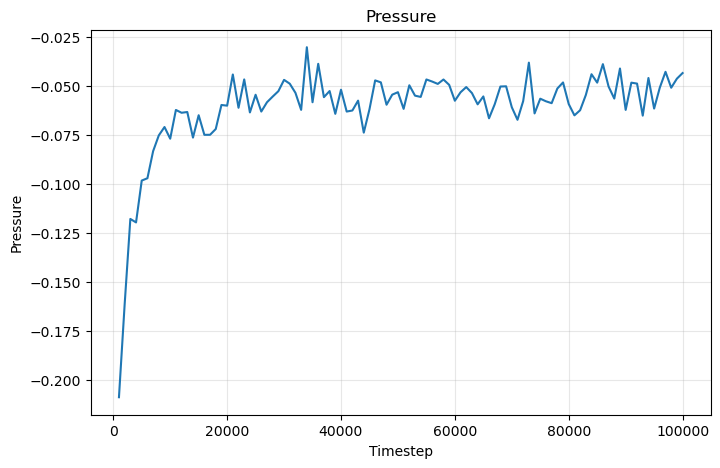

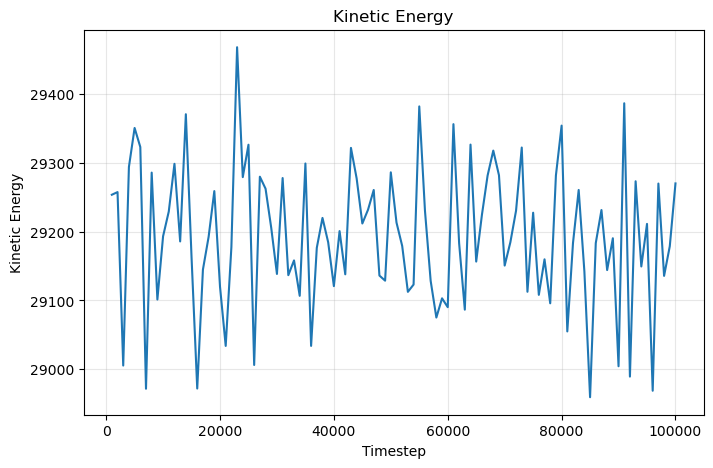

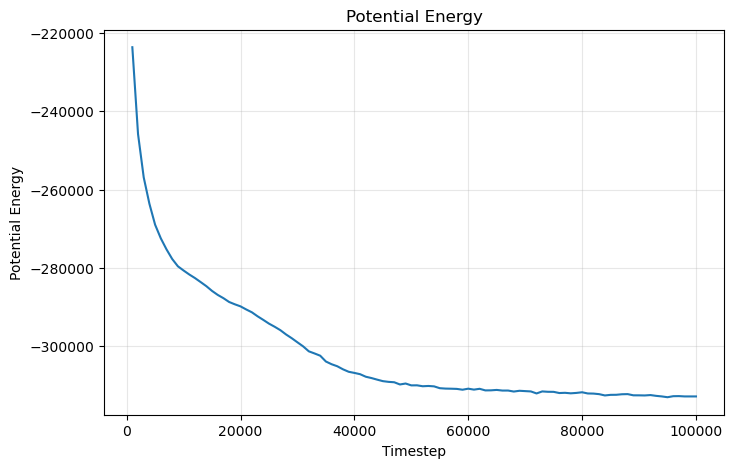

{'attrs': {'Lx': 50.0,
  'Ly': 50.0,
  'Lz': 50.0,
  'N': 48668,
  'actual_rho': 0.389344,
  'dt': 0.005,
  'epsilon_LJ': 1.0,
  'final_timestep': 100000,
  'kT': 0.4,
  'lj_mode': 'xplor',
  'log_period': 1000,
  'nsteps': 100000,
  'phase_name': 'randomization',
  'r_cut_LJ': 2.5,
  'r_on_LJ': 2.0,
  'seed': 1,
  'sigma_LJ': 1.0,
  'target_rho': 0.389344,
  'volume': 125000.0}}

In [3]:
log_path = "DualPhase/DualPhase_log.hdf5"
gsd_path = "DualPhase/DualPhase.gsd"

log = lh.read_hdf5_log(log_path)

vh.plot_log_quantity(log, "pressure")
vh.plot_log_quantity(log, "kinetic_energy")
vh.plot_log_quantity(log, "potential_energy")

log['metadata']

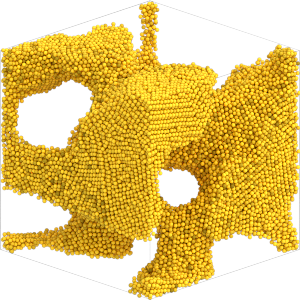

In [4]:
with gsd.hoomd.open(gsd_path, "r") as traj:
    frame = traj[0]

vh.render(frame)

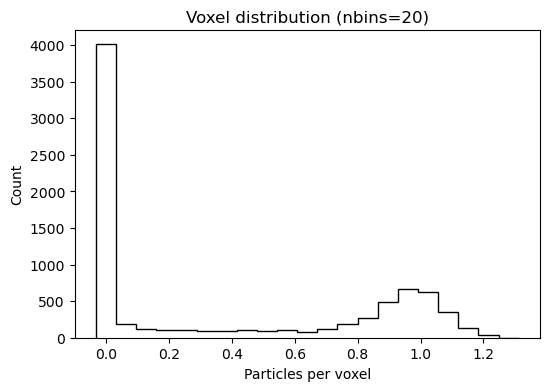

In [5]:
sim = hoomd.Simulation(device=hoomd.device.GPU(), seed=1)
sim.create_state_from_snapshot(frame)

vh.plot_voxel_histogram(sim, nbins=20, use_density=False);

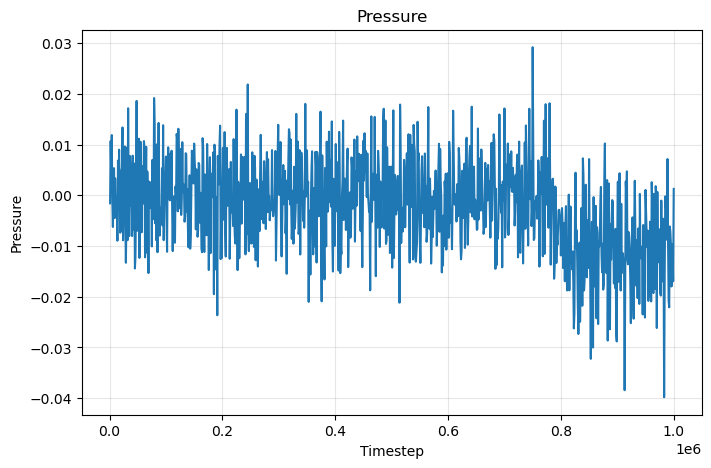

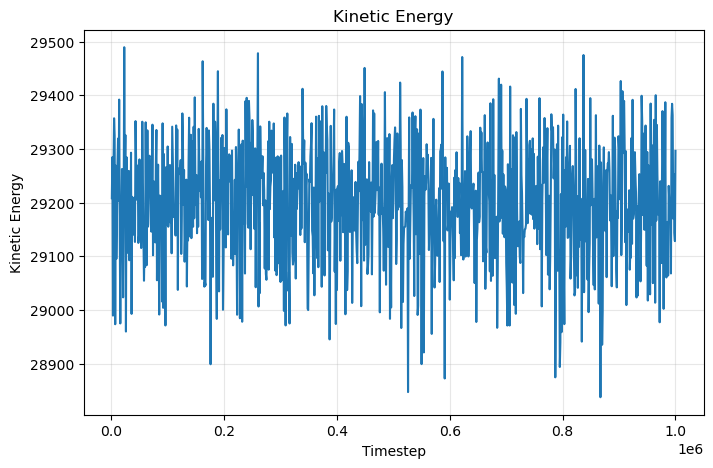

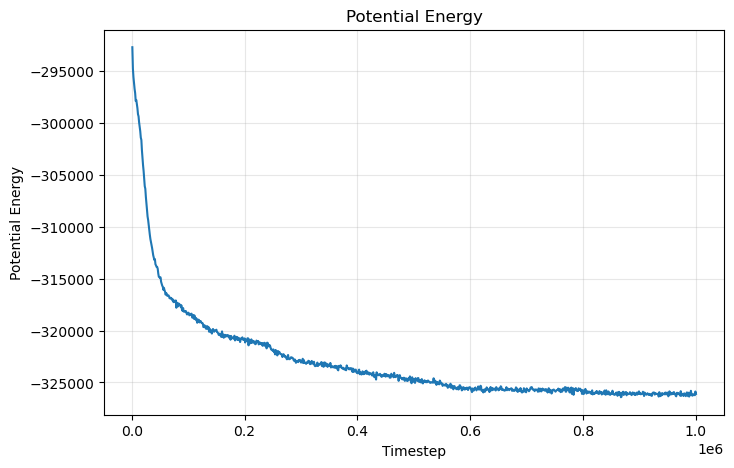

{'attrs': {'Lx': 50.0,
  'Ly': 50.0,
  'Lz': 50.0,
  'N': 48668,
  'actual_rho': 0.389344,
  'dt': 0.005,
  'epsilon_LJ': 1.0,
  'final_timestep': 1000000,
  'kT': 0.4,
  'lj_mode': 'xplor',
  'log_period': 1000,
  'nsteps': 1000000,
  'phase_name': 'randomization',
  'r_cut_LJ': 2.5,
  'r_on_LJ': 2.0,
  'seed': 1,
  'sigma_LJ': 1.0,
  'starting_state_path': '',
  'target_rho': 0.389344,
  'volume': 125000.0}}

In [6]:
log_path = "/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_1000000_log.hdf5"
gsd_path = "/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_1000000.gsd"

log = lh.read_hdf5_log(log_path)

vh.plot_log_quantity(log, "pressure")
vh.plot_log_quantity(log, "kinetic_energy")
vh.plot_log_quantity(log, "potential_energy")

log['metadata']

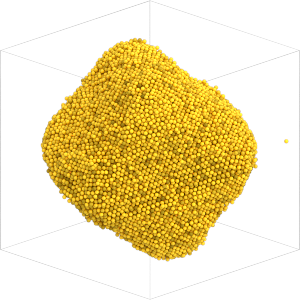

In [7]:
with gsd.hoomd.open(gsd_path, "r") as traj:
    frame = traj[0]

vh.render(frame)

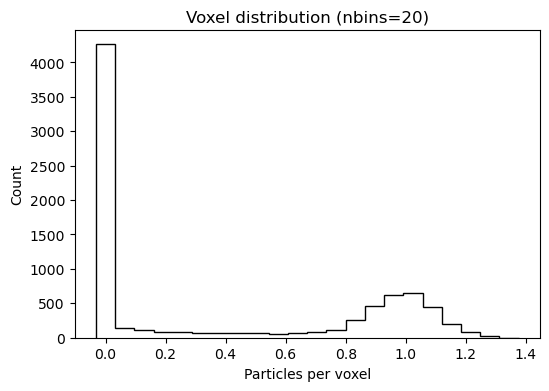

In [8]:
sim = hoomd.Simulation(device=hoomd.device.GPU(), seed=1)
sim.create_state_from_snapshot(frame)

vh.plot_voxel_histogram(sim, nbins=20, use_density=False);

Loaded existing lattice:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices/FCC/BoxLength_50.0/rho_0.40/lattice.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f9d381987d0>
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f9d674a68b0>
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f9d674a4c30>
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f9d6788bad0>
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f9d67517130>
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f9d67515480>
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7fa270404f50>
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f9d6751d150>
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f9d6747a4e0>
Starting Simulation --------------- F

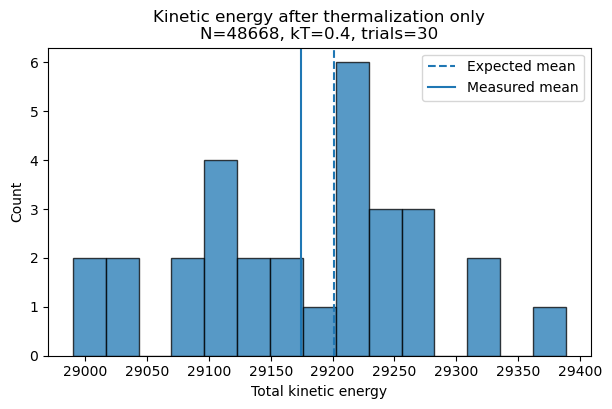

In [9]:
# ============================================================
# Sample kinetic energy after HOOMD velocity thermalization
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import hoomd

from md_Helpers import Create_Lattices as cl
from md_Helpers import Simulation_Helpers as sh

# ============================================================
# Inputs
# ============================================================

BoxLength = 50
rho = 0.4
kT = 0.4
n_trials = 30

kinetic_energies = []

# ============================================================
# Create/load starting FCC lattice
# ============================================================

frame = cl.make_lattice_frame(
    BoxLength=BoxLength,
    rho=rho,
    lattice_type="fcc",
)

N = frame.particles.N

# ============================================================
# Repeat thermalization only
# ============================================================

for trial in range(n_trials):
    seed = trial + 1

    sim = sh.make_simulation(
        frame,
        seed=seed,
        kT=kT,
    )

    sim.state.thermalize_particle_momenta(
        filter=hoomd.filter.All(),
        kT=kT,
    )

    thermo = hoomd.md.compute.ThermodynamicQuantities(
        filter=hoomd.filter.All()
    )

    sim.operations.computes.append(thermo)

    # Updates computes, but does not advance time
    sim.run(0)

    kinetic_energies.append(thermo.kinetic_energy)

kinetic_energies = np.array(kinetic_energies)

# ============================================================
# Summary
# ============================================================

expected_K = 1.5 * N * kT
std_K = np.sqrt(1.5 * N) * kT

print("Mean measured K =", kinetic_energies.mean())
print("Std measured K =", kinetic_energies.std(ddof=1))
print("Expected mean K =", expected_K)
print("Expected std K =", std_K)

# ============================================================
# Plot distribution
# ============================================================

plt.figure(figsize=(7, 4))

plt.hist(
    kinetic_energies,
    bins=15,
    edgecolor="black",
    alpha=0.75,
)

plt.axvline(expected_K, linestyle="--", label="Expected mean")
plt.axvline(kinetic_energies.mean(), linestyle="-", label="Measured mean")

plt.xlabel("Total kinetic energy")
plt.ylabel("Count")
plt.title(f"Kinetic energy after thermalization only\nN={N}, kT={kT}, trials={n_trials}")

plt.legend()
plt.show()